<a href="https://colab.research.google.com/github/kayodedada16-rgb/Ethical-AI-Analysis-and-Explainability/blob/main/Ethical_AI_Analysis_and_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Dataset Preparation & Preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load a sample dataset (using a standard classification dataset or synthetic equivalent for demonstration)
from sklearn.datasets import fetch_openml
data = fetch_openml(name='adult', version=1, as_frame=True)
df = data.frame.dropna().copy()

# For demonstration efficiency, take a representative sample
df = df.sample(n=10000, random_state=42)

# Define target variable (e.g., income >50K converted to binary)
df['target'] = (df['class'] == '>50K').astype(int)
df = df.drop(columns=['class'])

# Identify features, target, and sensitive attribute
sensitive_col = 'sex'  # Sensitive attribute for fairness analysis
y = df['target']
X = df.drop(columns=['target'])
sensitive_features = X[sensitive_col]

# Preprocessing for numerical and categorical data
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("Dataset shape:", df.shape)

Dataset shape: (10000, 15)


# Step 2: Model Training and Evaluation

In [2]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive_features, test_size=0.2, random_state=42, stratify=y
)

# Create and train logistic regression pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

# Predict and evaluate performance
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.859

Confusion Matrix:
 [[1388  107]
 [ 175  330]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      1495
           1       0.76      0.65      0.70       505

    accuracy                           0.86      2000
   macro avg       0.82      0.79      0.80      2000
weighted avg       0.85      0.86      0.86      2000



# Step 3: Fairness Analysis using Fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.1 MB/s eta 0:00:00
Metrics by Group:
        accuracy  selection_rate       fpr       tpr
sex                                                 
Female  0.927559        0.074016  0.017794  0.506849
Male    0.827106        0.285714  0.103966  0.678241


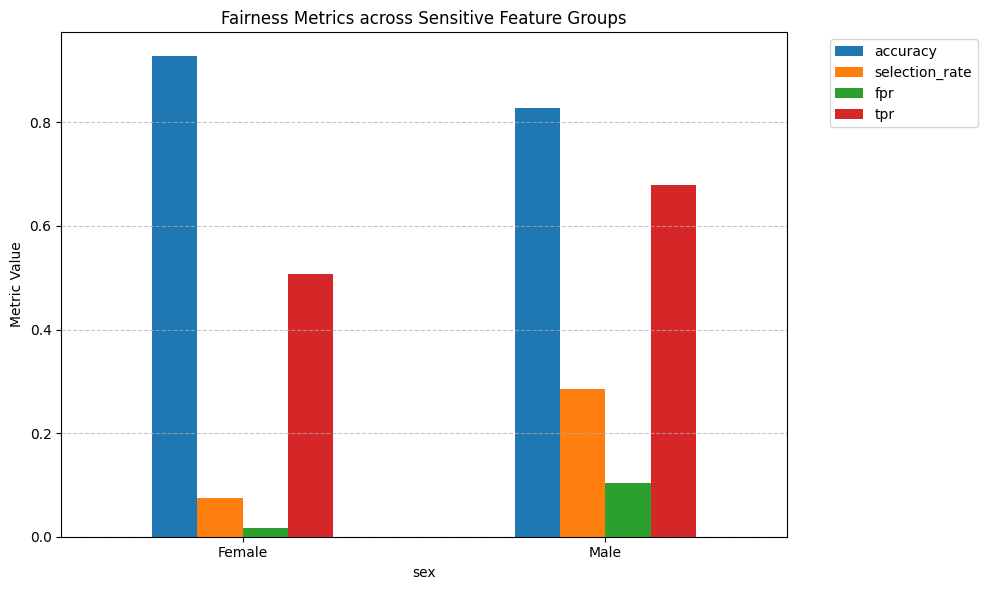

In [4]:
import matplotlib.pyplot as plt

!pip install fairlearn
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

# Define metrics to evaluate across groups
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'fpr': false_positive_rate,
    'tpr': true_positive_rate
}

# Create MetricFrame
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sens_test
)

print("Metrics by Group:")
print(metric_frame.by_group)

# Visualize fairness metrics using bar plots
metric_frame.by_group.plot(kind='bar', figsize=(10, 6))
plt.title("Fairness Metrics across Sensitive Feature Groups")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 4: Explainability Analysis (SHAP & LIME)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=d551752c7609859dfd72361d98928d0cd46d4a0a330fa76ab084317ad2a0b671
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


/usr/local/lib/python3.13/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


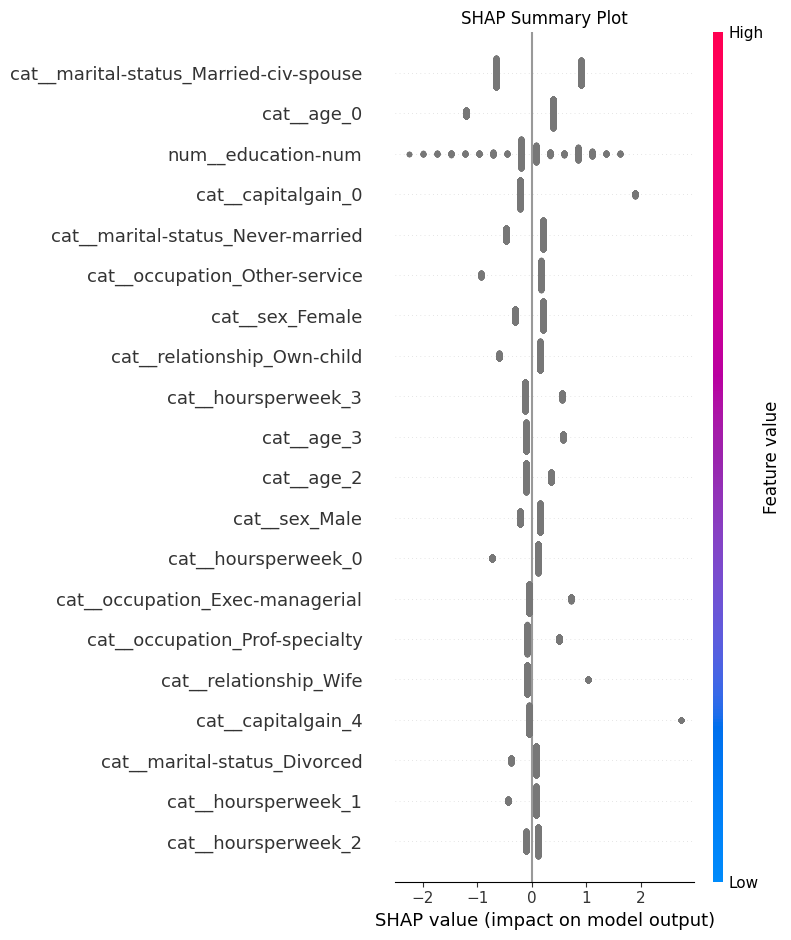

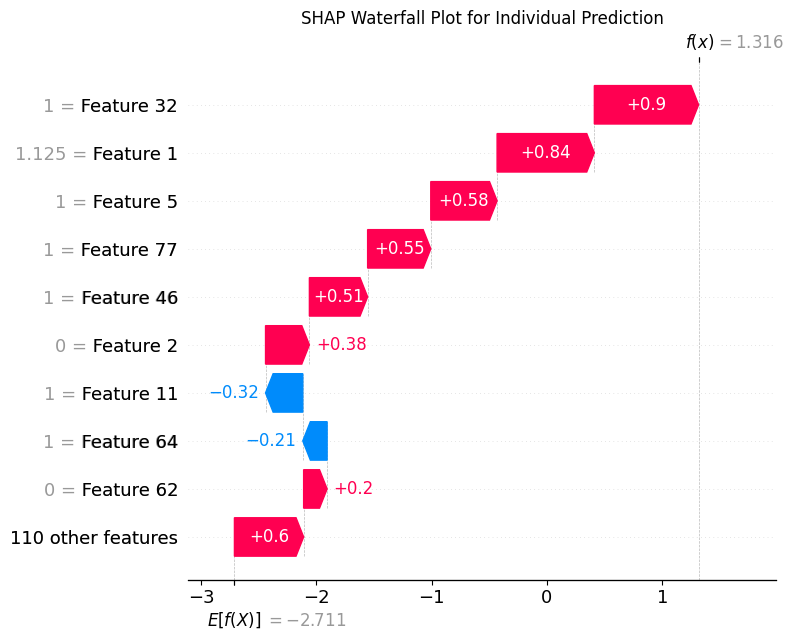

In [8]:
!pip install lime

import shap
import lime
import lime.lime_tabular


# Extract transformed feature names and preprocessed data for explainability
preprocessor.fit(X_train)
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Train a model directly on transformed arrays for tree/linear explainers
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(preprocessor.transform(X_train), y_train)

# --- SHAP Analysis ---
# Use LinearExplainer for logistic regression
explainer_shap = shap.LinearExplainer(log_reg, preprocessor.transform(X_train), feature_perturbation="interventional")
shap_values = explainer_shap(X_test_transformed)

# 1. SHAP Summary Plot (Global Explainability)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# 2. SHAP Waterfall Plot (Local Explainability for first test instance)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall Plot for Individual Prediction")
plt.tight_layout()
plt.show()

# --- LIME Analysis ---
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=preprocessor.transform(X_train),
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    mode='classification'
)

# Explain an individual prediction locally using LIME
exp = explainer_lime.explain_instance(
    data_row=X_test_transformed[0],
    predict_fn=log_reg.predict_proba
)

# Display LIME explanation
exp.show_in_notebook(show_table=True)